In [12]:
#-----------------------------
# Packages Import
#-----------------------------
%matplotlib inline

import numpy as np
from matplotlib import pyplot as plt

# Used to handle picture drawings
import cv2

# Used Handle directories and paths
import os

# Used to create and compute random angles
import random
import math

# Used to create the image labels
import json

# Handle and open the training data
import pandas as pd

# Avoid pythorch-KMP problem
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Pytorch  
import torch 

# Pytorch image functions
import torchvision
from torchvision.io import decode_image
from torchvision.io import read_image


# Dataloader and Data functions
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision import datasets

print(f"Torch version: {torch.__version__}")



Torch version: 2.4.1+cpu


In [13]:
#--------------------------
# Constants across the project
#----------------------------

# Mapping cardinal directions to approximate angles (in radians)
# Starting N at -90 degrees (standard Cartesian setup in image space)
DIRECTIONS = {
    "N":  -math.pi/2, "NE": -math.pi/4, "E": 0, "SE": math.pi/4,
    "S":   math.pi/2, "SW": 3*math.pi/4, "W": math.pi, "NW": -3*math.pi/4
}

DIRECTIONS_NUMBER= {
    "N":  1, "NE": 2, "E": 3, "SE": 4,
    "S":   5, "SW": 6, "W": 7, "NW": 8
}


DIR_KEYS = list(DIRECTIONS.keys())

In [14]:
# current working directory
path = os.getcwd()
# data directory
DATA_DIR = os.path.join(path, os.pardir,'data','local_Knot_training_data')

In [15]:
# Open and load the file
with open(os.path.join(DATA_DIR, "labels.json"), "r") as file:
    data = json.load(file)

#Creates an iterable with the filenames
filename=[label['filename'] for label in data ]
directions=[label['direction'] for label in data ]



In [16]:
#-----------------------------------------------
# This block Loads the data to train the model
#-----------------------------------------------

# I am defining a Dataset in torch following the tutorial at
# https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
class LocalKnotImageDataset(Dataset):
    def __init__(self, annotations_file, directions_file,img_dir, transform=None, target_transform=None):
        self.annotations_file = annotations_file
        #Ineed to change this to read my json data file. Not just to a given list of file names
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform
        self.directions_file= directions_file
        
    def __len__(self):
        return len(self.annotations_file)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.annotations_file[idx])
        #change the way I get  img_path
        #print(img_path)
        #-------------------------
        # TODO: THERE IS AN ISSUE WITH MY TORCH VERSION AND HAVE TO USE READ IMAGE INSTEAD OF DECODE IMAGE
        #---------------------------
        image = read_image(img_path)
        direction = DIRECTIONS_NUMBER[self.directions_file[idx]]
    
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            direction = self.transform(direction)
        return image, direction


In [17]:
#----------------------------------------
# We now prepare the train and test data
#----------------------------------------

#I have to change these methods to fit my custom datasets
training_data = LocalKnotImageDataset(
    annotations_file=filename, directions_file= directions,
    img_dir=DATA_DIR
)

test_data = LocalKnotImageDataset(
    annotations_file=filename, directions_file= directions,
    img_dir=DATA_DIR
)


BATCH_SIZE=1

train_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=True)

Feature batch shape: torch.Size([1, 3, 64, 64])
Labels batch shape: 1
torch.Size([3, 64, 64])
torch.Size([3, 64, 64])


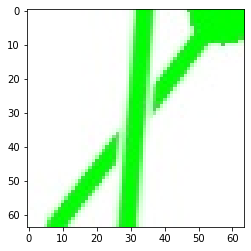

Label: 4


In [18]:
#--------------------------------------------------
# Check if the iterables in dataloader are working
#.--------------------------------------------------

from torchvision.transforms.functional import to_pil_image

# Display image and label.
train_features, train_labels = next(iter(train_dataloader))

train_features.size()

print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {len(train_labels)}")

print(train_features[0].size())

#img = train_features[10].squeeze()
img = train_features[0]
label = train_labels[0]

print(img.size())

#to_pil_image is necesarry because the tensor is of size [3,64,64] while plt.imshow take forms [64,64,3]
#Also plt takes numpyArrays and not tensors.
plt.imshow(to_pil_image(img), cmap="gray")
plt.show()
print(f"Label: {label}")

In [20]:
#-----------------------
# This block creates the Ml model to identify crossing and direction
#------------------------

import torch
import torch.nn as nn


#Hyperparameter Constants 
conv1_in=3
conv1_out=4
conv2_out=16

firstLayer=64
secondLayer=8

#----------------------------
# The architecture I used is the one similar to digit classifier 
# 2D-CONVOLUTION -> ReLU -> MAXPOOL -> 2D-CONVOLUTION -> ReLu -> Flatten
#
# This does not work at all. Need to find architerture.
#
#-----------------------------
'''
class Neural_Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(conv1_in, conv1_out, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(conv1_out, conv2_out, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
            #TODO READ ABOUT ADAPTATIVEAVGPOOL
        )
        self.fc = nn.Sequential(
            nn.Linear( conv2_out*conv2_out, firstLayer),
            #nn.Linear(conv2_out, firstLayer),
            nn.ReLU(),
            nn.Linear(firstLayer, secondLayer),
            nn.Softmax(dim=1) # Probabilities for the 40 states 8 lines + 16 under crossings+ 16 over crossings 
        )

    def forward(self, x):
        print(f"The shape of the input tensor is: {x.shape}")
        x = self.conv_layers(x)
        print(f"The shape of the input tensor after convolution is: {x.shape}")
        x = x.view(x.size(0), -1)
        print(f"The shape of the input tensor after reshaping is: {x.shape}")
        return self.fc(x)
'''



class Neural_Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(3*64*64, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 8)
        )

    def forward(self, x):
        print(f"The shape of the input tensor is: {x.shape}")
        x = self.flatten(x)
        print(f"The shape of the input tensor after flattening is: {x.shape}")
        logits = self.linear_relu_stack(x)
        return logits
   
    
model = Neural_Network()    

In [21]:
#------------------------------
# This block trains the model
#------------------------------


#-----------------------------------------
# Training loop
#-----------------------------------------
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode 
    # Not necessary for this case, since there is no batch renormalization layer, but is a good practice
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        #As given X is a tensor of integers have to cast them to float
        X=X.float()
        pred = model(X)
        loss = loss_fn(pred, y)
        
        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        
       # print(batch)
       # print(len(X))
        if batch % 10 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode  
    # Not necessary for this case, since there is no batch renormalization layer, but is a good practice
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            #As given X is a tensor of integers have to cast them to float
            X=X.float()
            print(X.dtype)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            #print(model(X))
            print(f"the predicted output is: {y}")
            print(f"the model output is:{pred.argmax(1)}")
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    
    


# Hyperparameters constants
learning_rate = 1e-1
batch_size = 1
epochs = 10



'''
We will use a Cross Entropy loss function. This is the standard for multi-class image classification. 
It ensures that the model outputs high probabilities for the correct class and low probabilities for others.
'''
# Initialize the loss function
loss_fn = nn.CrossEntropyLoss()

# We will use a Stochastic Gradiendt descent for the update of the model. This is standard
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
loss: 7.110908  [    1/  100]
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Si

The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
loss:     nan  [   71/  100]
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input ten

the predicted output is: tensor([2])
the model output is:tensor([0])
torch.float32
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
the predicted output is: tensor([2])
the model output is:tensor([0])
torch.float32
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
the predicted output is: tensor([6])
the model output is:tensor([0])
torch.float32
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
the predicted output is: tensor([6])
the model output is:tensor([0])
torch.float32
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
the predicted output is: tensor([7])
the model output is:tensor([0])
torch.float32
The shape of the input tensor is: torch.Size(

The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64,

The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torc

...

The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torc

the model output is:tensor([0])
torch.float32
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
the predicted output is: tensor([6])
the model output is:tensor([0])
torch.float32
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
the predicted output is: tensor([5])
the model output is:tensor([0])
torch.float32
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
the predicted output is: tensor([7])
the model output is:tensor([0])
torch.float32
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
the predicted output is: tensor([6])
the model output is:tensor([0])
torch.float32
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the inpu

The shape of the input tensor after flattening is: torch.Size([1, 12288])
loss:     nan  [    1/  100]
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input ten

The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
loss:     nan  [   71/  100]
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input ten

the predicted output is: tensor([5])
the model output is:tensor([0])
torch.float32
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
the predicted output is: tensor([7])
the model output is:tensor([0])
torch.float32
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
the predicted output is: tensor([7])
the model output is:tensor([0])
torch.float32
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
the predicted output is: tensor([4])
the model output is:tensor([0])
torch.float32
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
the predicted output is: tensor([3])
the model output is:tensor([0])
torch.float32
The shape of the input tensor is: torch.Size(

The shape of the numpy array is (64, 64)
The shape of the input tensor is: torch.Size([1, 3, 64, 64])
The shape of the input tensor after flattening is: torch.Size([1, 12288])
I think you drew a:tensor([[nan, nan, nan, nan, nan, nan, nan, nan]])


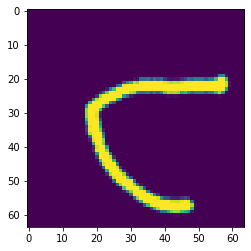

In [22]:
#---------------------------------------------------------------------------------------------
# This gives an interface to see if the model is well trained, testing in hand drawn examples
#---------------------------------------------------------------------------------------------

import tkinter as tk
from PIL import Image, ImageDraw
import numpy as np

class DrawerApp:
    def __init__(self, model_callback):
        self.root = tk.Tk()
        self.root.title("AI Image Classifier")
        self.model_callback = model_callback # Your model function goes here
        
        # Create Canvas
        self.canvas = tk.Canvas(self.root, width=280, height=280, bg='white')
        self.canvas.grid(row=0, column=0, columnspan=2)
        
        # Image buffer (to save what we draw)
        self.image = Image.new("L", (280, 280), "white")
        self.draw = ImageDraw.Draw(self.image)
        
        # Bind Mouse Events
        self.canvas.bind("<B1-Motion>", self.paint)
        
        # Buttons
        tk.Button(self.root, text="Classify", command=self.classify).grid(row=1, column=0)
        tk.Button(self.root, text="Clear", command=self.clear).grid(row=1, column=1)
        
    def paint(self, event):
        x1, y1 = (event.x - 8), (event.y - 8)
        x2, y2 = (event.x + 8), (event.y + 8)
        self.canvas.create_oval(x1, y1, x2, y2, fill="black", width=10)
        self.draw.ellipse([x1, y1, x2, y2], fill="black")

    def clear(self):
        self.canvas.delete("all")
        self.image = Image.new("L", (280, 280), "white")
        self.draw = ImageDraw.Draw(self.image)

    def classify(self):
        # Resize image to match model input (e.g., 28x28 for MNIST)
        img_resized = self.image.resize((64, 64))
        
        # Convert to NumPy and invert colors (often needed if model was trained on black background)
        img_array = np.array(img_resized)
        img_array = np.invert(img_array) 
        
        # Normalize and reshape for your specific model
        img_array = img_array / 255.0
        img_final = img_array.reshape(64, 64) # Example shape
        
        # Call your model!
        plt.imshow(img_final)
        prediction = self.model_callback(img_final)
        
        
        print(f"I think you drew a:{prediction}")

    def run(self):
        self.root.mainloop()

def my_model_predict(data):
    # call model.predict(data)
    print(f"The shape of the numpy array is {data.shape}")
    data = torch.from_numpy(data)
    data=data.float()
    #Reshape the [64,64] tensor to a [1,3,64,64] tensor
    data= data*torch.ones(1,3, 64, 64, )


    with torch.no_grad():
        pred = model(data)
    return pred

app = DrawerApp(my_model_predict)
app.run()
